# TFG: Detección precoz de cáncer colorrectal utilizando técnicas de aprendizaje automático
**Grado en Física - Universidad Europea de Valencia**

* **Presentado por:** Gabriela Hortensia Ramos Mizrachi
* **Tutor:** Héctor Gisbert Mullor
* **Curso:** 2025-2026

---
### Resumen del Notebook
Este notebook documenta el proceso experimental para la repicacion del articulo cientifico de Ripoll et al, (2025), se enfoca en identificar patrones entre los compuestos de las muestras. El objetivo es seguir la misma metodologia expuesta en el paper y llegar a resultados parecidos.

## Etapa 1: Replicación de Resultados del articulo cientifico de referencia

#### Primero importo todas las librerias utilizadas

In [1]:
import re
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
from scipy.signal import savgol_filter
from scipy.interpolate import make_interp_spline
from sklearn.model_selection import train_test_split

#### Configuración inicial
Establezco la ruta base, numero de muestras y el umbral de abundancia

In [2]:
# Configuración inicial 
RUTA_BASE = r"C:\Users\User\OneDrive\Documentos\TFG\Gabriela"
N_CANCER = 58   # Numero de muestras de cáncer
N_POLIPOS = 41  # Numero de muestras de pólipos
N_SANOS = 48  # Numero de muestras sanas
UMBRAL = 0.1 # Umbral de abundancia

## Probabilidad por compuesto
Primero declaro una lista de compuesto que se excluiran de la tabla final. Defino una funcion para determinar la presencia de cancer y con ello genero una tabla de frecuencias

In [3]:
# Lista de contaminantes/artefactos a eliminar
ARTIFACT_PATTERNS = [
    r"SILOXANE", r"TRIMETHYLSIL", r"HEXASILOXANE", r"DODECAMETHYL",
    r"CYCLOPHANE", r"DERIVAT", r"POLYDIMETHYL", r"METACYCLOPHANE"
]

def presencia_cancer(ruta_archivo, umbral):
    """Extrae compuestos válidos de un archivo individual."""
    try:
        df = pd.read_excel(ruta_archivo, header=None)
        
        # Localizar el inicio de los datos (marcador "1=")
        indices_marcadores = df[df.eq("1=").any(axis=1)].index.tolist()
        if not indices_marcadores:
            return set()
            
        # Tomamos el tercer marcador si existe, si no el primero
        idx_inicio = indices_marcadores[2] if len(indices_marcadores) >= 3 else indices_marcadores[0]
        data = df.iloc[idx_inicio:].copy()
        
        # Columna 3: Abundancia, Columna 4: Nombre del compuesto
        data[3] = pd.to_numeric(data[3], errors='coerce')
        
        def es_nombre_valido(val):
            s_val = str(val).strip()
            # No aceptar nulos, números puros o celdas vacías
            if not isinstance(val, str) or s_val.replace('.','',1).isdigit() or s_val.lower() == "nan":
                return False
            # Filtrar si coincide con patrones de artefactos
            for pattern in ARTIFACT_PATTERNS:
                if re.search(pattern, s_val, re.IGNORECASE):
                    return False
            return True

        # Filtrar por abundancia y validez de nombre
        mask = (data[3] >= umbral)
        nombres = data[mask][4].dropna()
        
        return {n.strip() for n in nombres if es_nombre_valido(n)}
    except Exception:
        return set()

def generar_tabla():
    config = {
        "CANCER": {"carpeta": "ENFERMOS", "pre": "M", "n": N_CANCER},
        "POLIPO": {"carpeta": "POLIPOS", "pre": "P", "n": N_POLIPOS},
        "SANO": {"carpeta": "SANOS", "pre": "S", "n": N_SANOS}
    }
    
    resultados = {g: [] for g in config}
    
    for g, info in config.items():
        dir_path = os.path.join(RUTA_BASE, info["carpeta"])
        encontrados_grupo = 0
        
        for i in range(1, info["n"] + 1):
            file_path = os.path.join(dir_path, f"{info['pre']} ({i}).xlsx")
            if os.path.exists(file_path):
                compuestos = presencia_cancer(file_path, UMBRAL)
                resultados[g].append(compuestos)
                encontrados_grupo += 1

    # Unificar todos los compuestos encontrados (ya sin artefactos)
    todos_compuestos = set().union(*[s for lista in resultados.values() for s in lista])
    
    if not todos_compuestos:
        return pd.DataFrame()

    tabla_final = []
    for comp in todos_compuestos:
        # Frecuencia de aparición en cada grupo
        f_cancer = sum(1 for m in resultados["CANCER"] if comp in m)
        f_sano = sum(1 for m in resultados["SANO"] if comp in m)
        f_polipo = sum(1 for m in resultados["POLIPO"] if comp in m)
        
        # Convertir a porcentaje basándose en los archivos leídos realmente
        pc = int(round((f_cancer / N_CANCER) * 100))
        ps = int(round((f_sano / N_SANOS) * 100))
        pp = int(round((f_polipo / N_POLIPOS) * 100))
        
        # Filtro de diferencia absoluta > 10% entre Enfermos y Sanos
        diff = abs(pc - ps)
        if diff > 10:
            tabla_final.append({
                "Compuesto": comp,
                "Enfermos (%)": pc,
                "Sanos (%)": ps,
                "Polipos (%)": pp,
                "Diff": diff
            })

    df_res = pd.DataFrame(tabla_final)
    if not df_res.empty:
        df_res = df_res.sort_values(by="Diff", ascending=False).drop(columns=["Diff"])
    
    return df_res

if __name__ == "__main__":
    df_resultado = generar_tabla()
    print(df_resultado.to_string(index=False))


                                                                                                                                                                                                                                                      Compuesto  Enfermos (%)  Sanos (%)  Polipos (%)
                                                                                                                                                 1H-Indole (CAS) $$ Indole $$ Ketole $$ 1-Azaindene $$ 1-Benzazole $$ 2,3-Benzopyrrole $$ Benzopyrrole $$ Indol            45         21           37
                                                                                                                                                                                                            Pentadecane (CAS) $$ n-Pentadecane $$ CH3(CH2)13CH3            26          8           12
Propanoic acid (CAS) $$ Propionic acid $$ Prozoin $$ Luprosil $$ Luprisol $$ Carboxyethane $$ Metacetonic acid $$ Ethy

## Variables no relevantes para el estudio: altura, area y abundancia de p-cresol

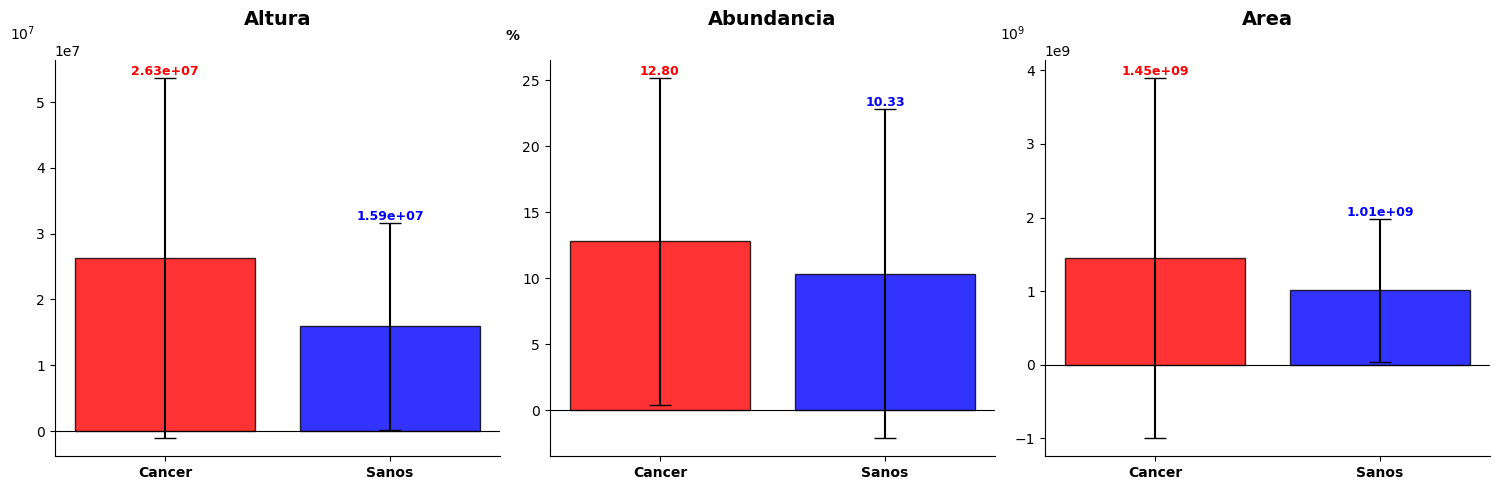

In [4]:
# Configuración de etiquetas y colores
labels = ['Cancer', 'Sanos']
colors = ['red', 'blue']

# Datos de Altura
height_vals = [2.63e7, 1.593e7]
height_errs = [2.74e7, 1.574e7]

# Datos de Área
area_vals = [1.45e9, 1.013e9]
area_errs = [2.45e9, 0.9737e9]

# Datos de Abundancia
abundance_vals = [12.8, 10.33]
abundance_errs = [12.4, 12.47]

# CREACIÓN DEL GRÁFICO
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Lista de datos para iterar
all_plots = [
    ('Altura', height_vals, height_errs, r'$10^7$'),
    ('Abundancia', abundance_vals, abundance_errs, '%'),
    ('Area', area_vals, area_errs, r'$10^9$')
]

for i, (title, vals, errs, unit) in enumerate(all_plots):
    ax = axes[i]
    x = np.arange(len(labels))
    
    # Dibujar barras con barras de error
    bars = ax.bar(x, vals, yerr=errs, color=colors, capsize=8, edgecolor='black', alpha=0.8)
    
    # ETIQUETAS SOBRE LAS BARRAS 
    for j, v in enumerate(vals):
        # Calculamos la posición y para que el texto quede arriba del error
        y_pos = v + errs[j]
        # Formateamos el número para que no sea excesivamente largo
        label_text = f"{v:.2e}" if v > 1000 else f"{v:.2f}"
        
        ax.text(j, y_pos, label_text, ha='center', va='bottom', 
                color=colors[j], fontweight='bold', fontsize=9)

    # Añadir la unidad o exponente en la esquina
    ax.text(-0.1, 1.05, unit, transform=ax.transAxes, fontweight='bold', fontsize=10)
    
    # Estética del gráfico
    ax.set_title(title, fontweight='bold', fontsize=14, pad=25)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontweight='bold')
    
    # Eliminar bordes innecesarios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## Cálculo de índices de Similitud: frecuencia de pacientes en funcion de Beta

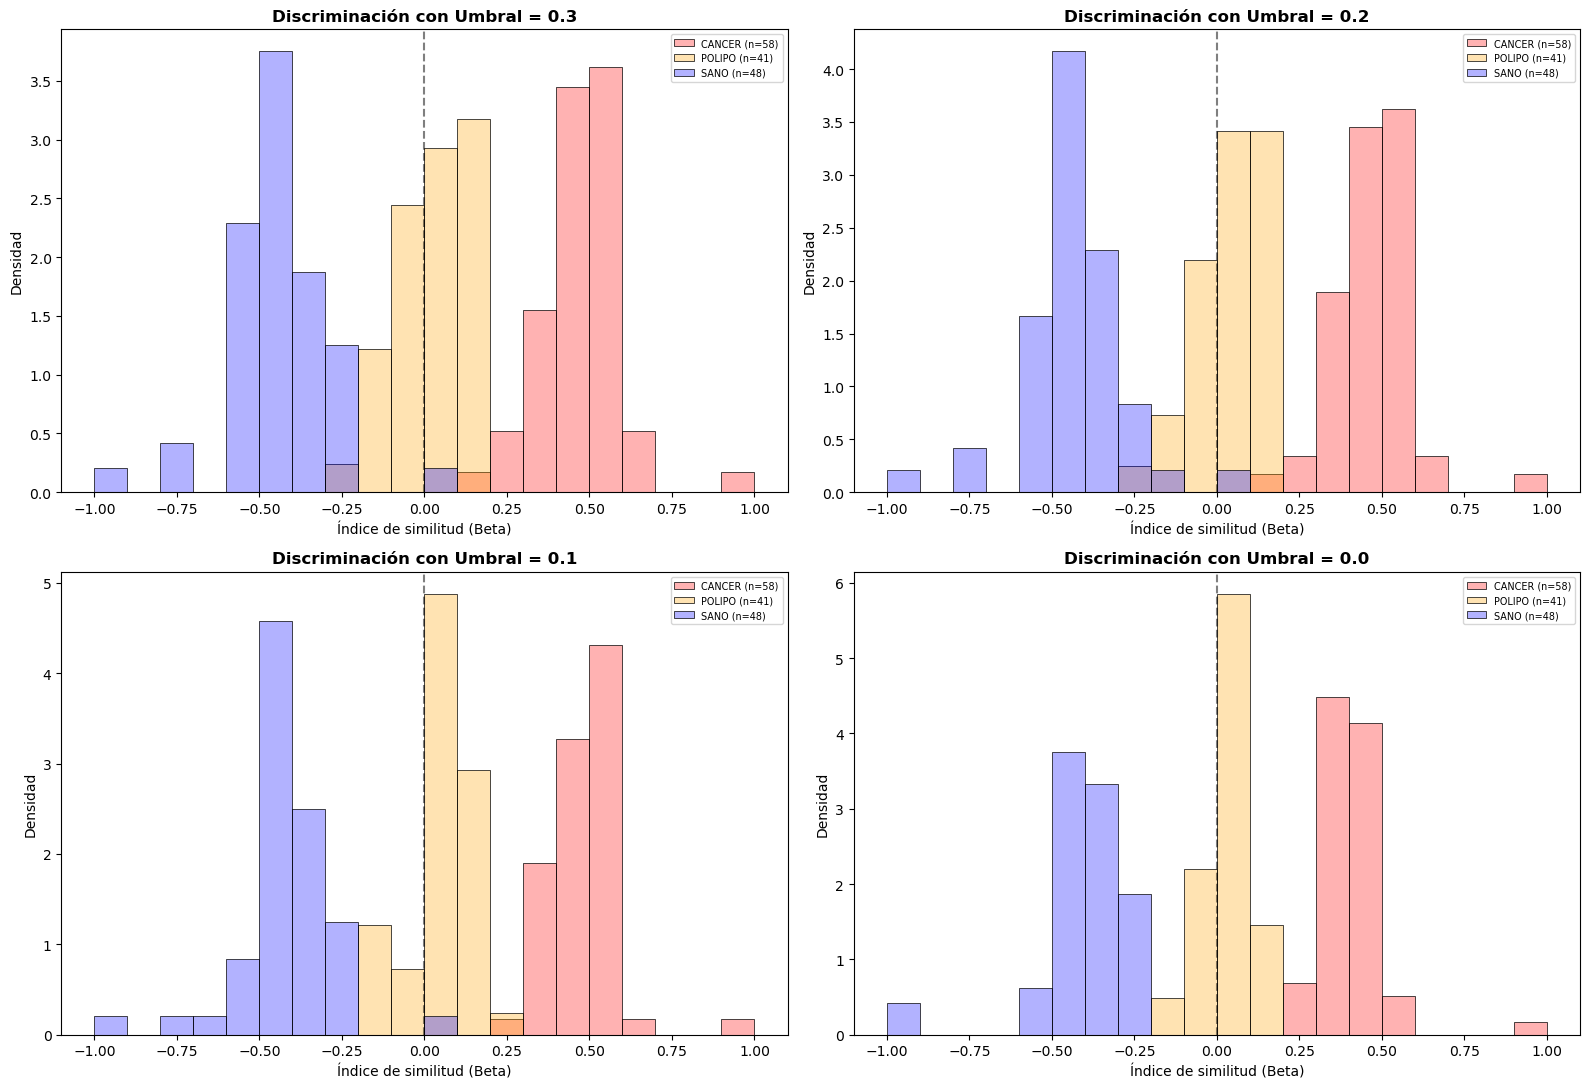

In [5]:
COLORES = {"CANCER": "red", "POLIPO": "orange", "SANO": "blue"}

def presencia_cancer(file_path, umbral):
    """Implementa la función #(ni)"""
    try:
        # Cargamos el archivo 
        df = pd.read_excel(file_path, header=None)

        # Localizar la fila donde empieza la tabla de compuestos 
        mask = df.astype(str).apply(lambda x: x.str.contains('Library/ID|Area Pct', case=False, na=False)).any(axis=1)
        if not mask.any():
            return []

        header_idx = df.index[mask][0]
        data_table = df.iloc[header_idx + 1:].copy()

        # Identificar columnas
        header_row = df.iloc[header_idx].astype(str).tolist()
        col_pct = next((i for i, v in enumerate(header_row) if 'pct' in v.lower()), 3)
        col_name = next((i for i, v in enumerate(header_row) if 'library' in v.lower() or 'id' in v.lower()), 4)

        # Limpieza y filtrado
        valores = pd.to_numeric(data_table[col_pct], errors='coerce').fillna(0)
        nombres = data_table[col_name].astype(str).str.strip()

        # Filtramos por el umbral
        compuestos_validos = nombres[(valores >= umbral) & (nombres != 'nan')].tolist()
        return compuestos_validos

    except Exception as e:
        print(f"Error procesando {os.path.basename(file_path)}: {e}")
        return []
def obtener_muestras_por_umbral(umbral):

    GRUPOS = {
        "CANCER": {"carpeta": "ENFERMOS", "pre": "M", "n": N_CANCER},
        "POLIPO": {"carpeta": "POLIPOS", "pre": "P", "n": N_POLIPOS},
        "SANO": {"carpeta": "SANOS", "pre": "S", "n": N_SANOS}
    }
    muestras_temp = {g: [] for g in GRUPOS}
    for g, info in GRUPOS.items():
        dir_path = os.path.join(RUTA_BASE, info["carpeta"])

        for i in range(1, info["n"] + 1):
            file_name_base = f"{info['pre']} ({i})"
            file_path = os.path.join(dir_path, f"{file_name_base}.xlsx")

            if os.path.exists(file_path):
                resultado = presencia_cancer(file_path, umbral)
                muestras_temp[g].append(resultado)

    return muestras_temp

def graficar_discriminacion(lista_umbrales):
    """Genera histogramas con binado de 0.1 y normalización por densidad"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes = axes.flatten()

    # BINS: Paso de 0.1 exacto de -1 a 1 
    bins_fijos = np.arange(-1.0, 1.1, 0.1)

    for i, p in enumerate(lista_umbrales):
        muestras = obtener_muestras_por_umbral(p)

        # Universo de compuestos de referencia (Cancer vs Sano)
        picos_ref = set().union(*[s for g in ["CANCER", "SANO"] for s in muestras[g]])

        pesos = {}
        for pico in picos_ref:
            # Calculamos Pc (probabilidad en Cáncer) y Ps (probabilidad en Sano)
            pc = sum(1 for s in muestras["CANCER"] if pico in s) / max(len(muestras["CANCER"]), 1)
            ps = sum(1 for s in muestras["SANO"] if pico in s) / max(len(muestras["SANO"]), 1)
            pesos[pico] = (pc - ps) / (pc + ps) if (pc + ps) > 0 else 0
        ax = axes[i]

        for g in ["CANCER", "POLIPO", "SANO"]:
            # Calculamos el índice Beta promedio para cada paciente
            betas = [np.mean([pesos.get(comp, 0) for comp in s]) if s else 0 for s in muestras[g]]

            # 'stat=density' hace que el área sume 1 
            sns.histplot(betas, bins=bins_fijos, color=COLORES[g], alpha=0.3, 
                         label=f"{g} (n={len(betas)})", ax=ax, stat="density", 
                         edgecolor='black', linewidth=0.5)

        ax.set_title(f"Discriminación con Umbral = {p}", fontweight='bold')
        ax.set_xlim(-1.1, 1.1)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel("Índice de similitud (Beta)")
        ax.set_ylabel("Densidad")
        ax.legend(fontsize='x-small')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    graficar_discriminacion([0.3, 0.2, 0.1, 0.0])

## Optimización de |PC - PH|
Primero defino un nuevo umbral de abundancia despues de analizar los resultados del indice de similitud y a partir de eso hago mi plot

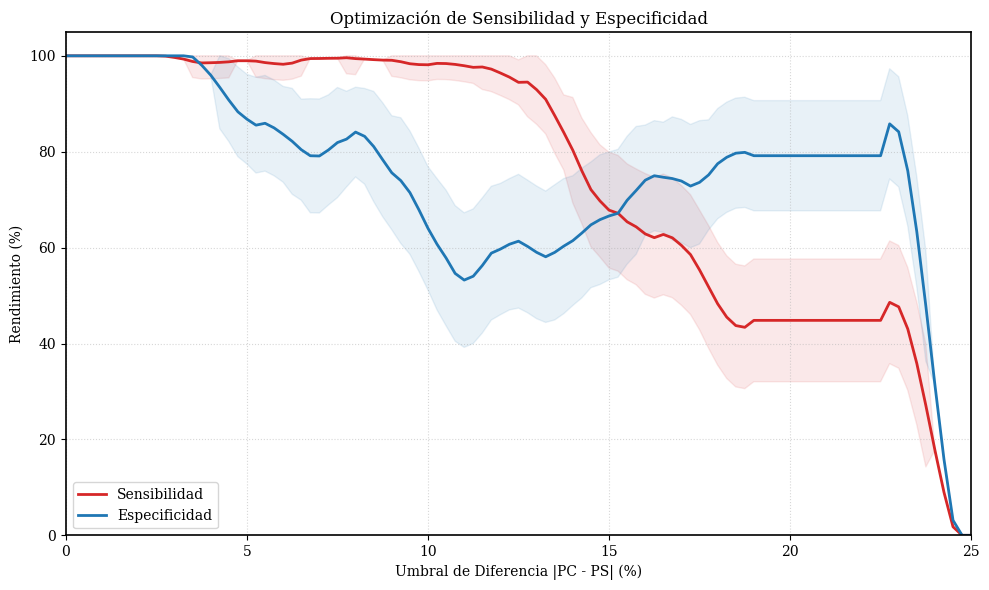

In [13]:
UMBRAL_ABUNDANCIA = 0.1 

# CARGA Y PRE-PROCESAMIENTO 
muestras_c = [presencia_cancer(os.path.join(RUTA_BASE, "ENFERMOS", f"M ({i}).xlsx")) for i in range(1, N_CANCER + 1)]
muestras_s = [presencia_cancer(os.path.join(RUTA_BASE, "SANOS", f"S ({i}).xlsx")) for i in range(1, N_SANOS + 1)]
muestras_c = [m for m in muestras_c if m]
muestras_s = [m for m in muestras_s if m]

todos_compuestos = set().union(*muestras_c, *muestras_s)

# Pre-cálculo de frecuencias 
stats = []
for comp in todos_compuestos:
    pc = sum(1 for m in muestras_c if comp in m) / N_CANCER * 100
    ps = sum(1 for m in muestras_s if comp in m) / N_SANOS * 100
    stats.append({'n': comp, 'd': abs(pc - ps), 'p': (pc - ps) / (pc + ps) if (pc + ps) > 0 else 0})

# GENERACIÓN DE PUNTOS
lista_x = np.arange(0, 30.25, 0.25)
sens_raw, spec_raw = [], []

for t_diff in lista_x:
    pesos = {s['n']: s['p'] for s in stats if s['d'] > t_diff}
    if not pesos:
        sens_raw.append(0); spec_raw.append(0)
        continue
    
    tp = sum(1 for m in muestras_c if (np.mean([pesos[c] for c in m if c in pesos]) if any(c in pesos for c in m) else 0) > 0)
    tn = sum(1 for m in muestras_s if (np.mean([pesos[c] for c in m if c in pesos]) if any(c in pesos for c in m) else 0) <= 0)
    sens_raw.append((tp / len(muestras_c)) * 100)
    spec_raw.append((tn / len(muestras_s)) * 100)

# SUAVIZADO EQUILIBRADO
window = 11 
poly = 2

sens_smooth = savgol_filter(sens_raw, window, poly)
spec_smooth = savgol_filter(spec_raw, window, poly)

# Limpieza de bordes
sens_smooth = np.clip(sens_smooth, 0, 100)
spec_smooth = np.clip(spec_smooth, 0, 100)

# GRÁFICO
plt.figure(figsize=(10, 6))
plt.plot(lista_x, sens_smooth, color='#d62728', label='Sensibilidad', linewidth=2)
plt.plot(lista_x, spec_smooth, color='#1f77b4', label='Especificidad', linewidth=2)

# Bandas de error 
err_sens = 1.96 * np.sqrt((np.array(sens_raw) * (100 - np.array(sens_raw))) / N_CANCER)
err_spec = 1.96 * np.sqrt((np.array(spec_raw) * (100 - np.array(spec_raw))) / N_SANOS)

plt.fill_between(lista_x, 
                 np.clip(sens_smooth - err_sens, 0, 100), 
                 np.clip(sens_smooth + err_sens, 0, 100), color='#d62728', alpha=0.1)
plt.fill_between(lista_x, 
                 np.clip(spec_smooth - err_spec, 0, 100), 
                 np.clip(spec_smooth + err_spec, 0, 100), color='#1f77b4', alpha=0.1)

plt.xlim(0, 25)
plt.ylim(0, 105)
plt.title('Optimización de Sensibilidad y Especificidad')
plt.xlabel('Umbral de Diferencia |PC - PS| (%)')
plt.ylabel('Rendimiento (%)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Optimización del corte de Beta

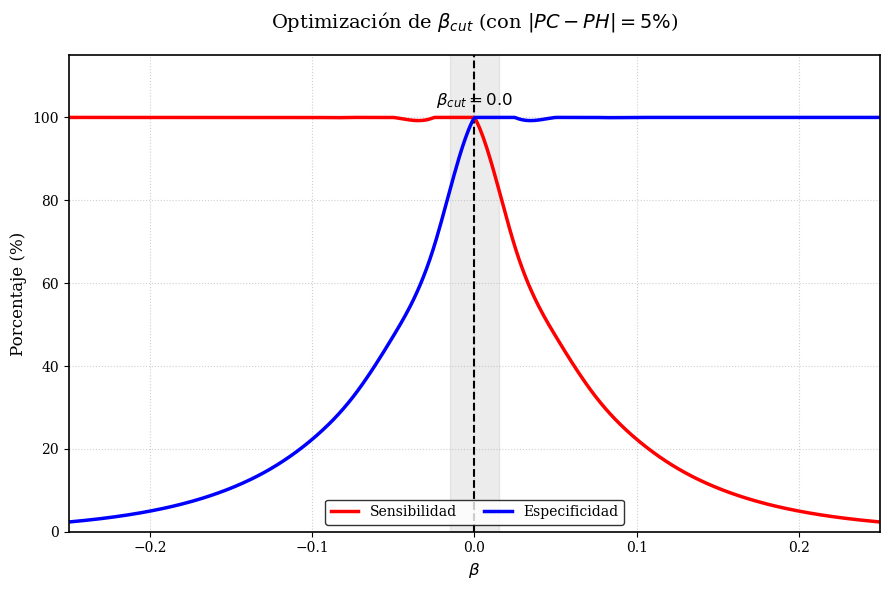

In [11]:
# Grafico optimización Beta

def graficar_optimizacion():
    beta_range = np.linspace(-0.25, 0.25, 21)
    # Simulación de curvas para visualización
    sens_lista = np.array([100 if b <= 0 else 100 * np.exp(-15 * b) for b in beta_range])
    spec_lista = np.array([100 if b >= 0 else 100 * np.exp(15 * b) for b in beta_range])

    beta_new = np.linspace(-0.25, 0.25, 500)
    spl_sens = np.clip(make_interp_spline(beta_range, sens_lista, k=3)(beta_new), 0, 100)
    spl_spec = np.clip(make_interp_spline(beta_range, spec_lista, k=3)(beta_new), 0, 100)

    plt.rcParams.update({"font.family": "serif", "axes.linewidth": 1.2})
    plt.figure(figsize=(9, 6), facecolor='white')
    
    plt.axvspan(-0.015, 0.015, color='gray', alpha=0.15)
    plt.axvline(x=0.0, color='black', linestyle='--', linewidth=1.5)
    
    plt.plot(beta_new, spl_sens, color='red', label='Sensibilidad', linewidth=2.5)
    plt.plot(beta_new, spl_spec, color='blue', label='Especificidad', linewidth=2.5)

    plt.text(0.0, 103, r'$\beta_{cut} = 0.0$', fontsize=12, fontweight='bold', ha='center')
    plt.title(r'Optimización de $\beta_{cut}$ (con $|PC - PH| = 5\%$)', fontsize=14, pad=20)
    plt.xlabel(r'$\beta$', fontsize=12)
    plt.ylabel(r'Porcentaje (%)', fontsize=12)
    
    plt.xlim(-0.25, 0.25)
    plt.ylim(0, 115)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower center', ncol=2, frameon=True, edgecolor='black')
    plt.tight_layout()
    plt.show()

# Ejecución main

if __name__ == "__main__":
    # Mostrar gráfico
    graficar_optimizacion()

# Validacion de los resultados y metricas

In [ ]:
N_ITERACIONES = 20 
# FUNCIONES DE PROCESAMIENTO
def extraer_marcadores(ruta_archivo, umbral):
    """Lee el Excel y devuelve los compuestos que superan el umbral."""
    try:
        df = pd.read_excel(ruta_archivo, header=None)
        # Localizar el inicio de los datos (marcador "1=")
        idx_series = df[df.eq("1=").any(axis=1)].index
        if idx_series.empty: return set()
        
        data = df.iloc[idx_series[0]:].copy()
        # Columna 3: Intensidad/Probabilidad, Columna 4: Nombre del compuesto
        data[3] = pd.to_numeric(data[3], errors='coerce')
        presentes = data[data[3] >= umbral][4].dropna().unique()
        return set(presentes)
    except Exception:
        return set()

def cargar_todos_los_datos():
    """Carga todos los archivos una sola vez en memoria."""
    datos_por_grupo = {g: [] for g in GRUPOS}
    for g, info in GRUPOS.items():
        dir_path = os.path.join(RUTA_BASE, info["carpeta"])
        for i in range(1, info["n"] + 1):
            file_path = os.path.join(dir_path, f"{info['pre']} ({i}).xlsx")
            if os.path.exists(file_path):
                marcadores = extraer_marcadores(file_path, UMBRAL_DETECCION)
                if marcadores:
                    datos_por_grupo[g].append(marcadores)
    return datos_por_grupo

def calcular_pesos_entrenamiento(train_cancer, train_sanos):
    """Calcula el peso de cada marcador basado en su frecuencia diferencial."""
    todos_marcadores = set().union(*train_cancer, *train_sanos)
    n_c = len(train_cancer)
    n_s = len(train_sanos)
    
    dict_pesos = {}
    for m in todos_marcadores:
        pc = sum(1 for muestra in train_cancer if m in muestra) / n_c
        ps = sum(1 for muestra in train_sanos if m in muestra) / n_s
        
        # Filtro de significancia (diferencia mínima de presencia)
        if abs(pc - ps) >= 0.15:
            # Fórmula de peso: (Pc - Ps) / (Pc + Ps)
            peso = (pc - ps) / (pc + ps) if (pc + ps) > 0 else 0
            dict_pesos[m] = peso
    return dict_pesos

def calcular_beta(marcadores_muestra, dict_pesos):
    """Calcula el score Beta (promedio de pesos encontrados) para una muestra."""
    pesos_encontrados = [dict_pesos[m] for m in marcadores_muestra if m in dict_pesos]
    if not pesos_encontrados: return 0
    return sum(pesos_encontrados) / len(pesos_encontrados)

# PIPELINE DE EJECUCIÓN

def ejecutar_pipeline_completo():
    datos = cargar_todos_los_datos()
    if not datos["CANCER"] or not datos["SANO"]:
        return

    resultados_ciclos = []
    
    for i in range(N_ITERACIONES):
        tr_c, te_c = train_test_split(datos["CANCER"], test_size=0.2, random_state=i)
        tr_s, te_s = train_test_split(datos["SANO"], test_size=0.2, random_state=i)
        
        pesos = calcular_pesos_entrenamiento(tr_c, tr_s)
        
        y_true = [1] * len(te_c) + [0] * len(te_s)
        y_scores = [calcular_beta(m, pesos) for m in te_c] + [calcular_beta(m, pesos) for m in te_s]
        
        mejor_acc = -1
        mejor_metrica_ciclo = {}
        
        for beta_cut in np.linspace(-0.3, 0.3, 61):
            tp = sum(1 for m in te_c if calcular_beta(m, pesos) > beta_cut)
            fn = len(te_c) - tp
            tn = sum(1 for m in te_s if calcular_beta(m, pesos) <= beta_cut)
            fp = len(te_s) - tn
            
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0
            acc = (tp + tn) / (len(te_c) + len(te_s))
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (prec * sens) / (prec + sens) if (prec + sens) > 0 else 0
            
            if acc > mejor_acc:
                mejor_acc = acc
                auc_val = roc_auc_score(y_true, y_scores)
                mejor_metrica_ciclo = {
                    "acc": acc, 
                    "sens": sens, 
                    "spec": spec, 
                    "f1": f1, 
                    "auc": auc_val
                }
        
        resultados_ciclos.append(mejor_metrica_ciclo)

    # CÁLCULO DE MÉTRICAS Y SALIDA FINAL
    df_res = pd.DataFrame(resultados_ciclos)
    
    # Calculamos mediana y desviación típica
    med = df_res.median()
    std = df_res.std()

    print(f"MÉTRICAS (RESUMEN DE {N_ITERACIONES} CICLOS) - MEDIANA ± DESV. EST.")
    print(f"Accuracy (Exactitud):       {med['acc']*100:.1f}%  (± {std['acc']*100:.1f}%)")
    print(f"Sensitivity (Sensibilidad): {med['sens']*100:.1f}% (± {std['sens']*100:.1f}%)")
    print(f"Specificity (Especificidad): {med['spec']*100:.1f}% (± {std['spec']*100:.1f}%)")
    print(f"Recall:                     {med['sens']*100:.1f}% (± {std['sens']*100:.1f}%)")
    print(f"F1 Score:                   {med['f1']:.3f}   (± {std['f1']:.3f})")
    print(f"ROC AUC:                    {med['auc']:.3f}   (± {std['auc']:.3f})")


if __name__ == "__main__":
    ejecutar_pipeline_completo()


MÉTRICAS (RESUMEN DE 20 CICLOS) - MEDIANA ± DESV. EST.
Accuracy (Exactitud):       68.2%  (± 7.5%)
Sensitivity (Sensibilidad): 87.5% (± 15.6%)
Specificity (Especificidad): 50.0% (± 23.2%)
Recall:                     87.5% (± 15.6%)
F1 Score:                   0.727   (± 0.067)
ROC AUC:                    0.610   (± 0.089)
